In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

BASE_DIR = "homeworks/HW08-09"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results_log = []

In [2]:
BATCH_SIZE = 128
VAL_RATIO = 0.2

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

full_train_dataset = datasets.EMNIST(root='./data', split="balanced", train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split="balanced", train=False, download=True, transform=transform)

n_total = len(full_train_dataset)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_train_dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {len(train_subset)}, Val size: {len(val_subset)}, Test size: {len(test_dataset)}")

x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: {x_batch.shape}, Labels shape: {y_batch.shape}")
print(f"Value range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512, 256], num_classes=47,
                 use_dropout=False, dropout_p=0.3, use_bn=False):
        super(MLP, self).__init__()
        self.use_dropout = use_dropout
        self.use_bn = use_bn

        layers = []
        prev_size = input_size

        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(p=dropout_p))
            prev_size = h_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

def get_model(config):
    return MLP(
        hidden_sizes=config['hidden_sizes'],
        use_dropout=config.get('use_dropout', False),
        dropout_p=config.get('dropout_p', 0.0),
        use_bn=config.get('use_bn', False)
    ).to(device)

100%|██████████| 562M/562M [00:02<00:00, 241MB/s]


Train size: 90240, Val size: 22560, Test size: 18800
Batch shape: torch.Size([128, 1, 28, 28]), Labels shape: torch.Size([128])
Value range: [-1.000, 1.000]


In [3]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        _, predicted = torch.max(logits, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            _, predicted = torch.max(logits, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    return total_loss / total, correct / total

def run_experiment(exp_id, model_config, opt_config, epochs, early_stop_patience=None):
    model = get_model(model_config).to(device)
    criterion = nn.CrossEntropyLoss()

    if opt_config['type'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=opt_config['lr'], weight_decay=opt_config.get('weight_decay', 0))
    elif opt_config['type'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=opt_config['lr'],
                              momentum=opt_config.get('momentum', 0),
                              weight_decay=opt_config.get('weight_decay', 0))

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    epochs_trained = 0

    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        epochs_trained = epoch + 1

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_val_loss = v_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if early_stop_patience and patience_counter >= early_stop_patience:
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    results_log.append({
        'experiment_id': exp_id,
        'dataset': 'EMNIST_balanced',
        'seed': SEED,
        'model_summary': f"H:{model_config['hidden_sizes']}, DO:{model_config.get('use_dropout',False)}, BN:{model_config.get('use_bn',False)}",
        'optimizer': opt_config['type'],
        'lr': opt_config['lr'],
        'momentum': opt_config.get('momentum', 0),
        'weight_decay': opt_config.get('weight_decay', 0),
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_acc,
        'best_val_loss': best_val_loss
    })

    return model, history, best_val_acc

In [4]:
BASE_MODEL_CONFIG = {
    'hidden_sizes': [512, 256],
    'use_dropout': False,
    'use_bn': False
}

BASE_OPT_CONFIG = {'type': 'Adam', 'lr': 1e-3, 'weight_decay': 0}
EPOCHS_A = 20

m_e1, h_e1, acc_e1 = run_experiment("E1", BASE_MODEL_CONFIG, BASE_OPT_CONFIG, EPOCHS_A)

cfg_e2 = BASE_MODEL_CONFIG.copy()
cfg_e2['use_dropout'] = True
cfg_e2['dropout_p'] = 0.3
m_e2, h_e2, acc_e2 = run_experiment("E2", cfg_e2, BASE_OPT_CONFIG, EPOCHS_A)

cfg_e3 = BASE_MODEL_CONFIG.copy()
cfg_e3['use_bn'] = True
m_e3, h_e3, acc_e3 = run_experiment("E3", cfg_e3, BASE_OPT_CONFIG, EPOCHS_A)

best_model_cfg = cfg_e3
m_e4, h_e4, acc_e4 = run_experiment("E4", best_model_cfg, BASE_OPT_CONFIG, EPOCHS_A, early_stop_patience=3)

torch.save(m_e4.state_dict(), os.path.join(ARTIFACTS_DIR, "best_model.pt"))

best_config_data = {
    "model": best_model_cfg,
    "optimizer": BASE_OPT_CONFIG,
    "seed": SEED,
    "dataset": "EMNIST_balanced",
    "early_stopping": True
}
with open(os.path.join(ARTIFACTS_DIR, "best_config.json"), 'w') as f:
    json.dump(best_config_data, f, indent=2)

print(f"E1 Acc: {acc_e1:.4f}, E2 Acc: {acc_e2:.4f}, E3 Acc: {acc_e3:.4f}, E4 Acc: {acc_e4:.4f}")

E1 Acc: 0.8386, E2 Acc: 0.8470, E3 Acc: 0.8520, E4 Acc: 0.8535


In [5]:
OPT_MODEL_CONFIG = cfg_e3
EPOCHS_B = 10

opt_o1 = {'type': 'Adam', 'lr': 0.5}
m_o1, h_o1, _ = run_experiment("O1", OPT_MODEL_CONFIG, opt_o1, EPOCHS_B)

opt_o2 = {'type': 'Adam', 'lr': 1e-6}
m_o2, h_o2, _ = run_experiment("O2", OPT_MODEL_CONFIG, opt_o2, EPOCHS_B)

opt_o3 = {'type': 'SGD', 'lr': 0.1, 'momentum': 0.9, 'weight_decay': 1e-4}
m_o3, h_o3, _ = run_experiment("O3", OPT_MODEL_CONFIG, opt_o3, 15)

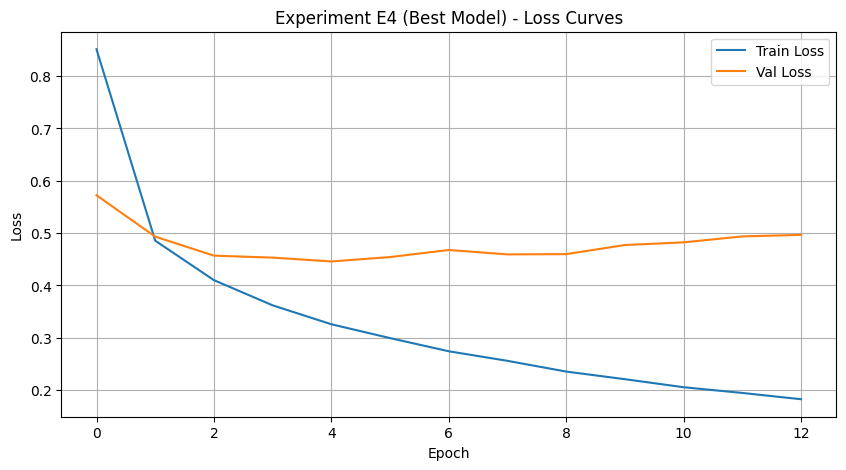

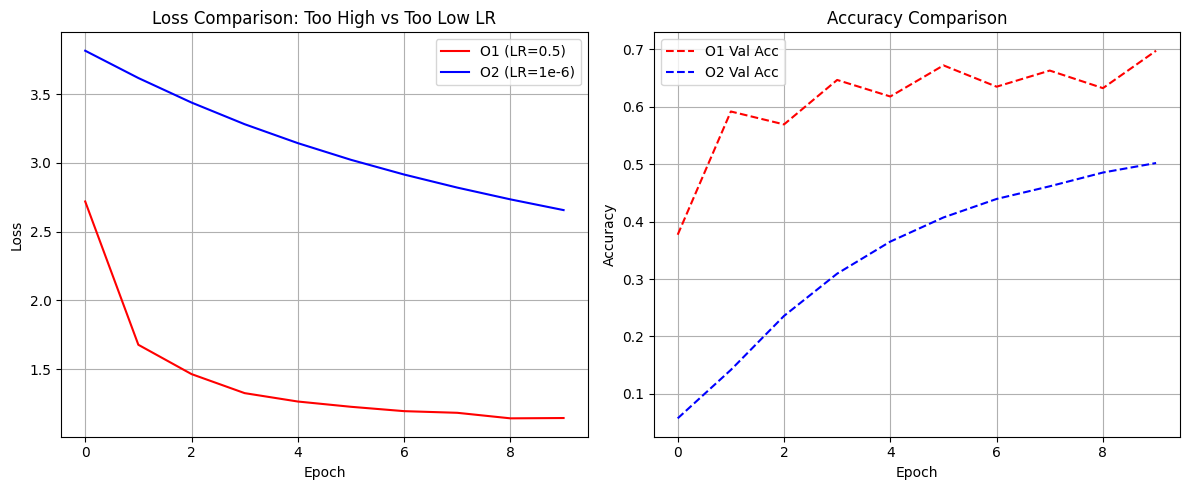

--- Final Test Evaluation (Best Model E4) ---
Test Accuracy: 0.8458, Test Loss: 0.5277


In [6]:
df_results = pd.DataFrame(results_log)
df_results.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)

plt.figure(figsize=(10, 5))
plt.plot(h_e4['train_loss'], label='Train Loss')
plt.plot(h_e4['val_loss'], label='Val Loss')
plt.title(f"Experiment E4 (Best Model) - Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "curves_best.png"))
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h_o1['train_loss'], label='O1 (LR=0.5)', color='red')
plt.plot(h_o2['train_loss'], label='O2 (LR=1e-6)', color='blue')
plt.title("Loss Comparison: Too High vs Too Low LR")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(h_o1['val_acc'], label='O1 Val Acc', color='red', linestyle='--')
plt.plot(h_o2['val_acc'], label='O2 Val Acc', color='blue', linestyle='--')
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"))
plt.show()

print("--- Final Test Evaluation (Best Model E4) ---")
m_e4.load_state_dict(torch.load(os.path.join(ARTIFACTS_DIR, "best_model.pt")))
test_loss, test_acc = evaluate(m_e4, test_loader, nn.CrossEntropyLoss(), device)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")